In [ ]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

**Introduction** \|\| [Tensors](tensors_deeper_tutorial.html) \|\|
[Autograd](autogradyt_tutorial.html) \|\| [Building
Models](modelsyt_tutorial.html) \|\| [TensorBoard
Support](tensorboardyt_tutorial.html) \|\| [Training
Models](trainingyt.html) \|\| [Model Understanding](captumyt.html)

Introduction to PyTorch
=======================

Follow along with the video below or on
[youtube](https://www.youtube.com/watch?v=IC0_FRiX-sw).



In [ ]:
# Run this cell to load the video
from IPython.display import display, HTML
html_code = """
<div style="margin-top:10px; margin-bottom:10px;">
  <iframe width="560" height="315" src="https://www.youtube.com/embed/IC0_FRiX-sw" frameborder="0" allow="accelerometer; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>
</div>
"""
display(HTML(html_code))



PyTorch Tensors
---------------

Follow along with the video beginning at
[03:50](https://www.youtube.com/watch?v=IC0_FRiX-sw&t=230s).  
下面步骤在视频开始[03:50](https://www.youtube.com/watch?v=IC0_FRiX-sw&t=230s).

First, we'll import pytorch.
首先，导入pytorch


In [ ]:
import torch

Let's see a few basic tensor manipulations. First, just a few of theways to create tensors:  
看一些基本的tensor计算。首先一些方法来创建tensor

In [ ]:
z = torch.zeros(5, 3)
print(z)
print(z.dtype)

Above, we create a 5x3 matrix filled with zeros, and query its datatypeto find out that the zeros are 32-bit floating point numbers, which isthe default PyTorch.  
在上面，创建了5*3的向量，填充为0，并且查询他的dtype，发现0的类型是32位的浮点数，这个是PyTorch的默认值

What if you wanted integers instead? You can always override the default:  
如果想要整数类型怎么办？你可以覆盖默认方式

In [ ]:
i = torch.ones((5, 3), dtype=torch.int16)  # 整数，非默认值，打印会告诉你
print(i)

You can see that when we do change the default, the tensor helpfully reports this when printed.  
你可以看见当我们改变默认值，tensor被打印的时候展示了这个新类型

It's common to initialize learning weights randomly, often with a specific seed for the PRNG for reproducibility of results:  
通常我们会随机初始化学习权重，通常会为伪随机数生成器（PRNG）设置特定的随机种子，以确保结果的可复现性


In [ ]:
torch.manual_seed(1729)  # 随机
r1 = torch.rand(2, 2)
print('A random tensor:')
print(r1)

r2 = torch.rand(2, 2)
print('\nA different random tensor:')
print(r2) # new values   两个不同，但r2还是固定的根据种子，不管生成时间

torch.manual_seed(1729)  # 指定后两者相同
r3 = torch.rand(2, 2)
print('\nShould match r1:')
print(r3) # repeats values of r1 because of re-seed 因为seed相同，值也下个堂

In [ ]:
d3= torch.rand(2, 3, 4)  # 3d = 2个二维矩阵
print(d3)

d4 = torch.rand(2, 2, 3, 4) # 4d = 2个三维矩阵
print(d4)

print(d4.shape)
print(d4.size()) # 等同于x.shape
print(d4.size(0),d4.size(1), d4.size(2)) # 输出第二维长度

PyTorch tensors perform arithmetic operations intuitively. Tensors of similar shapes may be added, multiplied, etc. Operations with scalars are distributed over the tensor:  
PyTorch 张量（tensors）的算术运算非常直观。形状相似的张量（tensors）可以进行相加、相乘等运算。标量与张量的运算，会自动分配（应用）到张量的每一个元素上。

In [ ]:
ones = torch.ones(2, 3)
print(ones)

twos = torch.ones(2, 3) * 2 # every element is multiplied by 2 每个元素乘2
print(twos)

threes = ones + twos       # addition allowed because shapes are similar 两个张量的形状相似，所以可以相加
print(threes)              # tensors are added element-wise 元素级相加
print(threes.shape)        # this has the same dimensions as input tensors 输出维度和输入张量相同   shape是tensor大小

r1 = torch.rand(2, 3)
r2 = torch.rand(3, 2)
# uncomment this line to get a runtime error   
# r3 = r1 + r2

Here's a small sample of the mathematical operations available:  
下面是数学运算可行的小例子


In [ ]:
r = (torch.rand(2, 2) - 0.5) * 2 # values between -1 and 1  固定随机值的范围
print('A random matrix, r:')
print(r)

# Common mathematical operations are supported:支持的操作
print('\nAbsolute value of r:')
print(torch.abs(r)) # 绝对值

# ...as are trigonometric functions: 用于计算输入张量（Tensor）中每个元素的反正弦值（arcsine）。它支持对单个值或多个值组成的张量进行逐元素计算。
print('\nInverse sine of r:')
print(torch.asin(r))

# ...and linear algebra operations like determinant and singular value decomposition  行列式和奇异值分解
print('\nDeterminant of r:')   
print(torch.det(r)) # 行列式  # print(torch.det(r1))  # 没有行列式
print('\nSingular value decomposition of r:')
print(torch.svd(r)) # 用于对输入矩阵进行奇异值分解（Singular Value Decomposition, SVD）。它可以将一个输入张量（通常形状为 (..., m, n)）分解为三个矩阵的组合。

# ...and statistical and aggregate operations: 统计和聚合操作
print('\nAverage and standard deviation of r:')
print(torch.std_mean(r)) #  是一个高效的统计计算函数，能够在一次操作中同时返回输入张量的标准差（Standard Deviation）和均值（Mean）。
print('\nMaximum value of r:')
print(torch.max(r))  # 获取整个张量的全局最大值

There's a good deal more to know about the power of PyTorch tensors, including how to set them up for parallel computations on GPU - we'll be going into more depth in another video.  
还有很多方法学习tensor的强大之处，包括如何将他们如何拆分成在GPU上的计算，之后其他视频会看更多

PyTorch Models
==============

Follow along with the video beginning at
[10:00](https://www.youtube.com/watch?v=IC0_FRiX-sw&t=600s).  
下面内容从[10:00](https://www.youtube.com/watch?v=IC0_FRiX-sw&t=600s)开始

Let's talk about how we can express models in PyTorch
让我们看看如何在pytorch中实现model

In [ ]:
import torch                     # for all things PyTorch 对于所有Pytorch
import torch.nn as nn            # for torch.nn.Module, the parent object for PyTorch models  模型
import torch.nn.functional as F  # for the activation function 激活函数

![](https://pytorch.org/tutorials/_static/img/mnist.png)

*Figure: LeNet-5*

Above is a diagram of LeNet-5, one of the earliest convolutional neural
nets, and one of the drivers of the explosion in Deep Learning. It was
built to read small images of handwritten numbers (the MNIST dataset),
and correctly classify which digit was represented in the image.  
上面是LeNet-5的图形，最早的一个CNN，并且并且是深度学习爆炸式增长的一个驱动力。
他被构建来读取小的手写图片（MNIST数据集），并且这千年正确分类出图片中的数字代表。


Here's the abridged version of how it works:  
以下是其工作原理的简要版本：

-   Layer C1 is a convolutional layer, meaning that it scans the input
    image for features it learned during training. It outputs a map of
    where it saw each of its learned features in the image. This
    "activation map" is downsampled in layer S2.  
    C1 层是一个卷积层，这意味着它会扫描输入图像，以寻找其在训练过程中学到的特征。它会输出一张映射图，显示它在图像的哪些位置发现了这些已学到的特征。这张“激活图”随后会在 S2 层进行下采样。
-   Layer C3 is another convolutional layer, this time scanning C1's
    activation map for *combinations* of features. It also puts out an
    activation map describing the spatial locations of these feature
    combinations, which is downsampled in layer S4.  
    C3 层是另一个卷积层，这一次它通过扫描 C1 层的激活图来提取特征的组合。同时，它也会输出一个激活图，用于描述这些特征组合在空间中的位置，随后这些空间位置信息会在 S4 层进行下采样。
-   Finally, the fully-connected layers at the end, F5, F6, and OUTPUT,
    are a *classifier* that takes the final activation map, and
    classifies it into one of ten bins representing the 10 digits.  
    最后全连接层再末尾，F5，F6和输出是一个*分类器*输入最后一个激活图，并且对始终类别做出一种分类得分。

How do we express this simple neural network in code?
在代码中我们如何实现这个简单神经网络？


In [ ]:
# m = nn.Linear(20, 30)
# print(m.weight)
# input = torch.randn(128, 20)
# output = m(input)
# print(output.size())

# m = nn.Linear(1,1)
# print(m.weight)
# print(m.bias)

# print(torch.__version__)


c = nn.Conv2d(3, 5, 5)
rand = torch.rand(3, 32, 32)
res = c(rand)
print(res.shape)

In [ ]:
class LeNet(nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input image channel (black & white), 6 output channels, 5x5 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b  仿射变换
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5*5 from image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Max pooling over a (2, 2) window  固定
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # If the size is a square you can only specify a single number，正方形，设置一个参数
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        # 在 PyTorch 中，x.view() 的核心作用是改变张量（Tensor）的形状（Shape），同时保持底层的数据内容不变。

        # 你可以把它想象成一块可以任意捏形的橡皮泥，或者同一张方格纸上画了一个新的网格——墨水（数据本身）没有移动，只是你分组和观察数据的方式（形状）改变了。

        # 以下是关于 x.view() 的几个核心要点及具体代码示例：

        # 基本用法与自动推断（-1的妙用）
        # 重塑形状：例如，一个包含12个元素的一维张量，可以通过 x.view(3, 4) 变成一个 3 times 4 的二维矩阵。
        # 使用 -1 占位符：如果你在某个维度上写 -1，PyTorch 会根据总元素数量和其他已知维度自动推断出该维度的大小。比如 x.view(-1) 可以将任意多维张量展平为一维；x.view(2, -1) 表示保留2行，列数由系统自动计算。

        # import torch

        # 创建一个包含12个元素的一维张量
        # x = torch.arange(12) 
        # print(x.shape)       # torch.Size([12])

        # 示例1：重塑为 3行4列 的二维矩阵
        # y = x.view(3, 4)     
        # print(y.shape)       # torch.Size([3, 4])

        # 示例2：使用 -1 自动推断列数 (12 / 2 = 6)
        # z = x.view(2, -1)    
        # print(z.shape)       # torch.Size([2, 6])

        # 示例3：将多维张量展平为一维
        # w = x.view(2, 3, 2).view(-1)  
        # print(w.shape)       # torch.Size([12])        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]  # all dimensions except the batch dimension.  [1:]取[0，1，2，3...]  [1，2，3...]这些值
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

Looking over this code, you should be able to spot some structural
similarities with the diagram above.  
看这个代码，能够发现一些和上面图片相似的地方

This demonstrates the structure of a typical PyTorch model:  
这个说明了一个典型pytorch模型的结构

-   It inherits from `torch.nn.Module` - modules may be nested - in
    fact, even the `Conv2d` and `Linear` layer classes inherit from
    `torch.nn.Module`.  
    它继承自 torch.nn.Module。模块是可以嵌套的——事实上，即使是 Conv2d 和 Linear 这样的层类，也是继承自 torch.nn.Module
-   A model will have an `__init__()` function, where it instantiates
    its layers, and loads any data artifacts it might need (e.g., an NLP
    model might load a vocabulary).  
    模型会包含一个 __init__() 函数，用于实例化（创建）各个网络层，并加载可能需要的任何数据资源（例如，一个自然语言处理模型可能会加载词表）。
-   A model will have a `forward()` function. This is where the actual
    computation happens: An input is passed through the network layers
    and various functions to generate an output.  
    模型还会包含一个 forward() 函数。这是实际进行计算的地方：输入数据会依次穿过网络的各个层和各种函数，最终生成输出结果。
-   Other than that, you can build out your model class like any other
    Python class, adding whatever properties and methods you need to
    support your model's computation.  
    除此之外，你可以像构建其他普通的 Python 类一样来构建你的模型类，根据需要添加任意属性和方法来支持模型的计算。

Let's instantiate this object and run a sample input through it.  
接下来，让我们实例化这个对象，并将一个样本输入传入其中运行一下。


In [ ]:
net = LeNet()
print(net)                         # what does the object tell us about itself?

input = torch.rand(1, 1, 32, 32)   # stand-in for a 32x32 black & white image
print('\nImage batch shape:')
print(input.shape)

output = net(input)                # we don't call forward() directly
# 是的，你的理解非常准确！这确实是 PyTorch 框架在底层帮你做了处理。

# 具体来说，这是利用了 Python 语言的一个内置特性（call 魔法方法）与 PyTorch 框架设计的巧妙结合。

# Python 的 call 机制
# 在 Python 中，如果你在一个类里定义了 call 方法，那么这个类的实例就可以像函数一样被直接调用。例如，当你执行 net(input) 时，Python 实际上是在触发 net.call(input)。

# PyTorch 的底层重写
# 你定义的 LeNet 类继承自 PyTorch 的基类 torch.nn.Module。在这个基类中，PyTorch 已经提前为你重写（实现）了 __call__ 方法。

# 当你调用 net(input) 时，实际发生的流程是：
# 触发继承自 nn.Module 的 call 方法。
# 这个 call 方法会在内部自动去调用你自己编写的 forward(self, x) 方法来完成前向传播计算。

# 💡 为什么框架要这样设计？
# 你可能会问：“既然最后都是调用 forward，为什么不直接写 net.forward(input) 呢？”

# 这是因为 nn.Module 中重写的 call 方法不仅仅是简单地转发给 forward，它还在幕后默默处理了许多关键的额外操作：
# 注册钩子函数（Hooks）：允许你在前向传播的前后插入自定义逻辑（比如调试、打印中间结果等）。
# 构建动态计算图与自动求导：为后续的梯度反向传播（Backward）铺路。
# 状态检查：确保模型处于正确的训练或评估模式。

# 因此，PyTorch 官方强烈建议：永远不要直接调用 model.forward(x)。通过像普通函数一样调用实例 model(x)，才能确保框架的所有附加功能正常生效。
print('\nRaw output:')
print(output)
print(output.shape)

There are a few important things happening above:  
上面的代码中发生了几件重要的事情：

First, we instantiate the `LeNet` class, and we print the `net` object.
A subclass of `torch.nn.Module` will report the layers it has created
and their shapes and parameters. This can provide a handy overview of a
model if you want to get the gist of its processing.  
实例化 LeNet 类：我们首先创建了 LeNet 类的一个实例，并打印了 net 对象。由于 LeNet 继承自 torch.nn.Module，它会自动报告所创建的层、各层的形状（shape）以及参数信息。这对于快速了解模型结构和处理逻辑非常有帮助。

Below that, we create a dummy input representing a 32x32 image with 1
color channel. Normally, you would load an image tile and convert it to
a tensor of this shape.  
创建虚拟输入：接着，我们创建了一个代表 32x32 图像的虚拟输入张量，其中包含 1 个颜色通道（例如灰度图）。在实际应用中，通常会加载图像切片并将其转换为这种形状的张量。

You may have noticed an extra dimension to our tensor - the *batch
dimension.* PyTorch models assume they are working on *batches* of data
- for example, a batch of 16 of our image tiles would have the shape
`(16, 1, 32, 32)`. Since we're only using one image, we create a batch
of 1 with shape `(1, 1, 32, 32)`.  
你可能已经注意到我们的张量多出了一个维度，即 批次维度（batch dimension）。
PyTorch 模型默认处理的是一批数据（batches of data）。例如，包含 16 张图像切片的批次形状应为 (16, 1, 3im2, 32)。
由于我们这里只使用一张图像，因此创建了一个大小为 1 的批次，形状为 (1, 1, 32, 32)。

We ask the model for an inference by calling it like a function:
`net(input)`. The output of this call represents the model's confidence
that the input represents a particular digit. (Since this instance of
the model hasn't learned anything yet, we shouldn't expect to see any
signal in the output.) Looking at the shape of `output`, we can see that
it also has a batch dimension, the size of which should always match the
input batch dimension. If we had passed in an input batch of 16
instances, `output` would have a shape of `(16, 10)`.  
我们通过像调用函数一样调用模型 net(input) 来请求模型进行推理。
输出含义：输出结果代表了模型对该输入图像属于某个特定数字类别的置信度（概率）。
输出形状：观察 output 的形状，可以看到它同样包含批次维度，且大小始终与输入的批次维度匹配。如果输入是 16 个实例的批次，output 的形状将是 (16, 10)（假设是 10 分类任务）。

Datasets and Dataloaders  
数据集与数据加载器
========================

Follow along with the video beginning at
[14:00](https://www.youtube.com/watch?v=IC0_FRiX-sw&t=840s).  
请从视频 14:00 开始跟随演示。

Below, we're going to demonstrate using one of the ready-to-download,
open-access datasets from TorchVision, how to transform the images for
consumption by your model, and how to use the DataLoader to feed batches
of data to your model.  
接下来，我们将演示如何使用 TorchVision 中即开即用的公开数据集之一，如何将图像转换为模型可接受的格式，以及如何使用 DataLoader 将数据批次馈送到模型中。

The first thing we need to do is transform our incoming images into a
PyTorch tensor.  
我们需要做的第一件事是将输入图像转换为 PyTorch 张量（Tensor）。

In [ ]:
!pwd
from torch.utils.data import ConcatDataset
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='/Users/suyapeng/Projects/AI/2026summer/deeplearning-101/Pytorch-official-document/Introduction to PyTorch_YouTube/data', train=True, download=True, transform=transform)

x = torch.stack([sample[0] for sample in ConcatDataset([trainset])])  
# #ConcatDataset([trainset])， 输出Dataset对象: https://docs.pytorch.org/docs/2.12/data.html#torch.utils.data.ConcatDataset
# torch.stack, 堆叠照片，50000张照片

[std, mean] = torch.std_mean(x, dim=(0,2,3))
print(mean, std)
transform = transforms.Compose(
    [transforms.ToTensor(),  # 图片转成向量
     transforms.Normalize(mean, std)]
     )


Here, we specify two transformations for our input:  
在这里，我们为输入指定了两种变换

-   `transforms.ToTensor()` converts images loaded by Pillow into
    PyTorch tensors.  
    transforms.ToTensor() 将 Pillow 加载的图像转换为 PyTorch 张量。

-   `transforms.Normalize()` adjusts the values of the tensor so that
    their average is zero and their standard deviation is 1.0. Most
    activation functions have their strongest gradients around x = 0, so
    centering our data there can speed learning. The values passed to
    the transform are the means (first tuple) and the standard
    deviations (second tuple) of the rgb values of the images in the
    dataset. You can calculate these values yourself by running these
    few lines of code:  
    transforms.Normalize() 调整张量的值，使其平均值为零，标准差为 1.0。大多数激活函数在 x = 0 附近具有最强的梯度，因此将数据以该点为中心可以加快学习速度。传递给该变换的值是数据集中图像 RGB 值的均值（第一个元组）和标准差（第二个元组）。你可以通过运行以下几行代码自行计算这些值：

```python
from torch.utils.data import ConcatDataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                download=True, transform=transform)

# stack all train images together into a tensor of shape 
# (50000, 3, 32, 32)
x = torch.stack([sample[0] for sample in ConcatDataset([trainset])])

# get the mean of each channel            
mean = torch.mean(x, dim=(0,2,3)) # tensor([0.4914, 0.4822, 0.4465])
std = torch.std(x, dim=(0,2,3)) # tensor([0.2470, 0.2435, 0.2616])  
```

There are many more transforms available, including cropping, centering,
rotation, and reflection.  
还有许多其他可用的变换，包括裁剪、居中、旋转和翻转。

Next, we'll create an instance of the CIFAR10 dataset. This is a set of
32x32 color image tiles representing 10 classes of objects: 6 of animals
(bird, cat, deer, dog, frog, horse) and 4 of vehicles (airplane,
automobile, ship, truck):
接下来，我们将创建一个 CIFAR10 数据集的实例。这是一组 32x32 的彩色图像块，代表 10 个类别的物体：6 种动物（鸟、猫、鹿、狗、青蛙、马）和 4 种交通工具（飞机、汽车、船、卡车）：


In [ ]:
trainset = torchvision.datasets.CIFAR10(root='/Users/suyapeng/Projects/AI/2026summer/deeplearning-101/Pytorch-official-document/Introduction to PyTorch_YouTube/data', train=True,
                                        download=True, transform=transform)

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>When you run the cell above, it may take a little time for thedataset to download.</p>
<p>当你运行上面的单元格时，数据集的下载可能需要花费一点时间。</p>

</div>

This is an example of creating a dataset object in PyTorch. Downloadable
datasets (like CIFAR-10 above) are subclasses of
`torch.utils.data.Dataset`. `Dataset` classes in PyTorch include the
downloadable datasets in TorchVision, Torchtext, and TorchAudio, as well
as utility dataset classes such as `torchvision.datasets.ImageFolder`,
which will read a folder of labeled images. You can also create your own
subclasses of `Dataset`.  
这是 PyTorch 中创建数据集对象的一个示例。可下载的数据集（如上面的 CIFAR-10）都是 torch.utils.data.Dataset 的子类。PyTorch 中的 Dataset 类包括 TorchVision、Torchtext 和 TorchAudio 中的可下载数据集，以及诸如 torchvision.datasets.ImageFolder 之类的实用数据集类，后者可以读取带有标签的图像文件夹。你也可以创建自己的 Dataset 子类。

When we instantiate our dataset, we need to tell it a few things:  
在实例化我们的数据集时，需要向它提供以下信息：

-   The filesystem path to where we want the data to go.  
    我们希望将数据存储到的文件系统路径。
-   Whether or not we are using this set for training; most datasets
    will be split into training and test subsets.  
    是否将此数据集用于训练；大多数数据集会被划分为训练集和测试集子集。
-   Whether we would like to download the dataset if we haven't already.  
    如果尚未下载，是否希望下载该数据集。
-   The transformations we want to apply to the data.  
    我们希望应用于数据的变换。

Once your dataset is ready, you can give it to the `DataLoader`:  
一旦你的数据集准备就绪，就可以将其传递给 DataLoader：


In [ ]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

A `Dataset` subclass wraps access to the data, and is specialized to the
type of data it's serving. The `DataLoader` knows *nothing* about the
data, but organizes the input tensors served by the `Dataset` into
batches with the parameters you specify.  
Dataset 子类封装了对数据的访问，并且会针对其提供的数据类型进行专门处理。DataLoader 对数据本身一无所知，但它会根据你指定的参数，将 Dataset 提供的输入张量组织成批次（batches）。


In the example above, we've asked a `DataLoader` to give us batches of 4
images from `trainset`, randomizing their order (`shuffle=True`), and we
told it to spin up two workers to load data from disk.  
在上面的示例中，我们要求 DataLoader 从 trainset（训练集）中每次提供包含 4 张图像的批次，随机打乱它们的顺序（shuffle=True），并启动两个工作进程（workers）来从磁盘加载数据。

It's good practice to visualize the batches your `DataLoader` serves:  
可视化 DataLoader 提供的批次是一个很好的实践：

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # matplotlib底层依赖numpy，必须转换成numpy调用， mat和pytorch向量维度也不同

trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)
# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images)) # 将一批图像（Batch Tensor）拼接排列成一个网格形式（Grid）的单张大图片。
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

Running the above cell should show you a strip of four images, and the
correct label for each.  
运行上面的单元格应该会显示一排四张图像，以及每张图像对应的正确标签。


Training Your PyTorch Model  
训练你的 PyTorch 模型
===========================

Follow along with the video beginning at  
[17:10](https://www.youtube.com/watch?v=IC0_FRiX-sw&t=1030s).
请从视频的 [17:10] 开始跟随讲解。

Let's put all the pieces together, and train a model:  
让我们把所有部分组合在一起，训练一个模型：


In [20]:
#%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

First, we'll need training and test datasets. If you haven't already,
run the cell below to make sure the dataset is downloaded. (It may take
a minute.)  
首先，我们需要训练集和测试集数据集。如果你还没有下载，请运行下面的单元格以确保数据集已下载（这可能需要一分钟时间）。


In [21]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2) # num_workers子进程加载数据集

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

We'll run our check on the output from `DataLoader`:  
我们将对 DataLoader 的输出进行检查：

 bird   cat truck plane


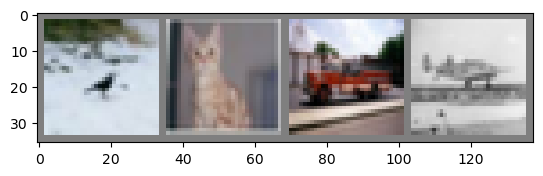

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

This is the model we'll train. If it looks familiar, that's because it's
a variant of LeNet - discussed earlier in this video - adapted for
3-color images.  
这就是我们将要训练的模型。如果它看起来很眼熟，那是因为它是在本视频前面讨论过的 LeNet 的一个变体，并且针对三色（RGB）图像进行了调整。


In [23]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

The last ingredients we need are a loss function and an optimizer:  
我们还需要最后两个要素：一个损失函数和一个优化器：

In [24]:
criterion = nn.CrossEntropyLoss()

# params = iter(net.parameters())
# print(next(params).shape)
# print(next(params).shape)
# print(next(params).shape)
for param in net.parameters():
    print(param.shape)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

torch.Size([6, 3, 5, 5])
torch.Size([6])
torch.Size([16, 6, 5, 5])
torch.Size([16])
torch.Size([120, 400])
torch.Size([120])
torch.Size([84, 120])
torch.Size([84])
torch.Size([10, 84])
torch.Size([10])


The loss function, as discussed earlier in this video, is a measure of
how far from our ideal output the model's prediction was. Cross-entropy
loss is a typical loss function for classification models like ours.  
正如本视频前面所讨论的，损失函数（loss function）衡量的是模型预测结果与理想输出之间的差距。交叉熵损失（Cross-entropy loss）是像我们这类分类模型常用的损失函数。

The **optimizer** is what drives the learning. Here we have created an
optimizer that implements *stochastic gradient descent,* one of the more
straightforward optimization algorithms. Besides parameters of the
algorithm, like the learning rate (`lr`) and momentum, we also pass in
`net.parameters()`, which is a collection of all the learning weights in
the model - which is what the optimizer adjusts.  
正如本视频前面所讨论的，损失函数（loss function）衡量的是模型预测结果与理想输出之间的差距。交叉熵损失（Cross-entropy loss）是像我们这类分类模型常用的损失函数。
优化器（optimizer）则是驱动模型学习的核心。在这里，我们创建了一个实现*随机梯度下降（stochastic gradient descent）*的优化器，这是最直观的优化算法之一。除了算法本身的参数（如学习率 lr 和动量 momentum）之外，我们还需要传入 net.parameters()，它包含了模型中所有需要学习的权重——这正是优化器要调整的对象。

Finally, all of this is assembled into the training loop. Go ahead and
run this cell, as it will likely take a few minutes to execute:  
最后，我们将以上所有内容整合到训练循环中。请运行这个单元格，它的执行可能需要花费几分钟的时间：


In [25]:
for epoch in range(1):  # loop over the dataset multiple times
    # range(5) -> [0, 1, 2, 3, 4] range 对象是一种惰性（Lazy）序列如果你需要真正的数组，就必须显式地进行转换： 转为 Python 列表：list(range(2)) -> [0, 1]转为 NumPy 数组：np.array(range(2)) -> array([0, 1])

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels) # https://www.qianwen.com/quarkshare/apps/mshare/routes/share-v3?biz_id=ai_chat_v2&env=prod&share_id=cc8cd780be164fae8a3262e619ccd5e2&source_client=pc&feature_chat_domain=https%3A%2F%2Fchat-api-quark2.qianwen.com
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.185
[1,  4000] loss: 1.865
[1,  6000] loss: 1.663
[1,  8000] loss: 1.615
[1, 10000] loss: 1.540
[1, 12000] loss: 1.494
Finished Training


Here, we are doing only **2 training epochs** (line 1) - that is, two
passes over the training dataset. Each pass has an inner loop that
**iterates over the training data** (line 4), serving batches of
transformed input images and their correct labels.  
在这里，我们只进行 2 个训练轮次（epochs）（第 1 行）——也就是说，对整个训练数据集遍历两次。每次遍历都有一个内部循环，用于迭代训练数据（第 4 行），提供经过变换的输入图像批次及其对应的正确标签。

**Zeroing the gradients** (line 9) is an important step. Gradients are
accumulated over a batch; if we do not reset them for every batch, they
will keep accumulating, which will provide incorrect gradient values,
making learning impossible.  
梯度清零（第 9 行）是一个重要步骤。梯度会在一个批次内累积；如果我们不为每个批次重置它们，梯度就会不断累加，导致计算出错误的梯度值，从而使模型无法学习。

In line 12, we **ask the model for its predictions** on this batch. In
the following line (13), we compute the loss - the difference between
`outputs` (the model prediction) and `labels` (the correct output).  
在第 12 行，我们让模型对当前批次进行预测。在下一行（第 13 行），我们计算损失——即 outputs（模型预测值）和 labels（正确输出值）之间的差异。

In line 14, we do the `backward()` pass, and calculate the gradients
that will direct the learning.  
在第 14 行，我们执行 backward() 反向传播，并计算用于指导学习的梯度。

In line 15, the optimizer performs one learning step - it uses the
gradients from the `backward()` call to nudge the learning weights in
the direction it thinks will reduce the loss.  
在第 15 行，优化器执行一步学习操作——它利用 backward() 调用产生的梯度，朝着它认为能降低损失的方向微调学习权重。

The remainder of the loop does some light reporting on the epoch number,
how many training instances have been completed, and what the collected
loss is over the training loop.  
循环的剩余部分会进行一些简单的报告，包括当前的轮次编号、已完成的训练样本数量以及训练循环中累积的损失值。

**When you run the cell above,** you should see something like this:  
当你运行上面的单元格时， 你应该能看到类似这样的输出：

``` {.sh}
[1,  2000] loss: 2.235
[1,  4000] loss: 1.940
[1,  6000] loss: 1.713
[1,  8000] loss: 1.573
[1, 10000] loss: 1.507
[1, 12000] loss: 1.442
[2,  2000] loss: 1.378
[2,  4000] loss: 1.364
[2,  6000] loss: 1.349
[2,  8000] loss: 1.319
[2, 10000] loss: 1.284
[2, 12000] loss: 1.267
Finished Training
```

Note that the loss is monotonically descending, indicating that our
model is continuing to improve its performance on the training dataset.  
请注意，损失值是单调递减的，这表明我们的模型在训练集上的表现正在持续提升。

As a final step, we should check that the model is actually doing
*general* learning, and not simply "memorizing" the dataset. This is
called **overfitting,** and usually indicates that the dataset is too
small (not enough examples for general learning), or that the model has
more learning parameters than it needs to correctly model the dataset.  
作为最后一步，我们应该检查模型是否真正实现了泛化学习，而不是仅仅“死记硬背”了数据集。这被称为过拟合（overfitting），通常表明数据集太小（没有足够的样本用于泛化学习），或者模型拥有的学习参数多于正确建模该数据集所需的参数。

This is the reason datasets are split into training and test subsets -to
test the generality of the model, we ask it to make predictions on data
it hasn't trained on:  
这就是将数据集划分为训练集和测试集子集的原因——为了测试模型的泛化能力，我们需要让它在未参与训练的数据上进行预测：


In [84]:
import debug

correct = 0
total = 0
saver = debug.ParamSaver(target_step=20)

with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        saver.step(data, outputs)  
        

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 47 %


125
labels  deer  bird   cat horse
predicted  bird   cat plane horse


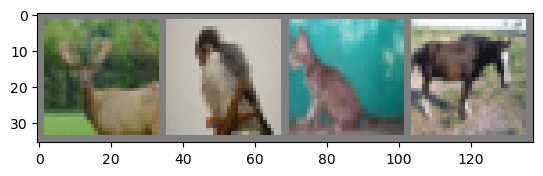

In [93]:
[data, outputs] = saver.get_params()[10]
print(saver.get_params().__len__())

images, labels = data
_, predicted = torch.max(outputs.data, 1)


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # matplotlib底层依赖numpy，必须转换成numpy调用， mat和pytorch向量维度也不同

# show images
imshow(torchvision.utils.make_grid(images)) # 将一批图像（Batch Tensor）拼接排列成一个网格形式（Grid）的单张大图片。
# print labels
print('labels', ' '.join('%5s' % classes[labels[j]] for j in range(4)))
print('predicted', ' '.join('%5s' % classes[predicted[j]] for j in range(4)))

If you followed along, you should see that the model is roughly 50%
accurate at this point. That's not exactly state-of-the-art, but it's
far better than the 10% accuracy we'd expect from a random output. This
demonstrates that some general learning did happen in the model.  
如果你跟着操作到了这一步，你会发现此时模型的准确率大约在 50% 左右。这虽然算不上最先进的水平，但已经远远优于随机输出时我们预期的 10% 准确率。这表明模型确实发生了一定程度的泛化学习。
